This project requires Python 3.7 or above and Scikit-Learn ≥ 1.0.1:

In [2]:
# 버전 체크
import sys
from packaging import version
import sklearn

assert sys.version_info >= (3, 7), f"Python 3.7+ 필요 (현재: {sys.version})"
assert version.parse(sklearn.__version__) >= version.parse("1.0.1"), \
    f"scikit-learn 1.0.1+ 필요 (현재: {sklearn.__version__})"

print(f"Python: {sys.version.split()[0]}")
print(f"scikit-learn: {sklearn.__version__}")


Python: 3.13.5
scikit-learn: 1.7.1


# DecisionTree

1️⃣ MNIST 데이터 로드

In [3]:
# MNIST 70,000 로드
from sklearn.datasets import fetch_openml
import numpy as np

# OpenML에서 MNIST 전체(70,000) 불러오기
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32)          # (70000, 784)
y = mnist.target.astype(np.int64)          # (70000,)

print("X shape:", X.shape, "\ny shape:", y.shape)
print("클래스:", np.unique(y))

X shape: (70000, 784) 
y shape: (70000,)
클래스: [0 1 2 3 4 5 6 7 8 9]


2️⃣ 교차검증

In [4]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv


StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

3️⃣ GridSearch 설정

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, ParameterGrid

# --- GridSearchCV ---
dt = DecisionTreeClassifier(random_state=42)
dt_param = {
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 10, 50],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}
# 총 후보 수 계산
total_candidates = len(ParameterGrid(dt_param))
print(f"총 후보 수: {total_candidates}")


총 후보 수: 72


4️⃣ 예상 시간 추정

In [7]:
import numpy as np, time
from sklearn.model_selection import cross_val_score

# 1) 테스트할 기본 모델 (최적화 없이 단순한 기본 DecisionTree로 1회 CV 시간 측정)
dt_test = DecisionTreeClassifier(random_state=42)

start = time.time()
_ = cross_val_score(dt_test, X, y, cv=cv, n_jobs=-1)  
end = time.time()

time_per_cv = end - start
print(f"✅ 1개 조합 × 5-Fold 검증 소요 시간: {time_per_cv:.2f}초")

# 2) 총 예상 시간 계산
estimated_time = total_candidates * time_per_cv
minutes = estimated_time / 60
hours = minutes / 60

print(f"⏳ 예상 총 실행시간: 약 {estimated_time:.1f}초 ≈ {minutes:.1f}분")


✅ 1개 조합 × 5-Fold 검증 소요 시간: 41.00초
⏳ 예상 총 실행시간: 약 2952.2초 ≈ 49.2분


5️⃣ GridSearchCV 실행 (최적 모델 탐색)

In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

dt_gs = GridSearchCV(dt, dt_param, cv=cv, n_jobs=-1, scoring="accuracy", verbose=1)
dt_gs.fit(X, y)

print("DT best acc:", dt_gs.best_score_)
print("DT best params:", dt_gs.best_params_)
for k, v in dt_gs.best_params_.items():
    print("   ", k, "=", v)

# 상위 결과 미리 정렬해보기
cvres = (
    pd.DataFrame(dt_gs.cv_results_)
    .sort_values("mean_test_score", ascending=False)
    .loc[:, ["mean_test_score","std_test_score",
             "param_max_depth","param_min_samples_split","param_min_samples_leaf",
             "param_class_weight"]]
    .head(10)
)

print("\n📊 Top 10 결과:")
display(cvres)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
DT best acc: 0.8780142857142857
DT best params: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 5, 'min_samples_split': 2}
    class_weight = balanced
    max_depth = 30
    min_samples_leaf = 5
    min_samples_split = 2

📊 Top 10 결과:


,mean_test_score,std_test_score,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_class_weight
70,0.878014,0.002995,30,10,5,balanced
69,0.878014,0.002995,30,2,5,balanced
43,0.877943,0.002727,None,10,5,balanced
42,0.877943,0.002727,None,2,5,balanced
60,0.877471,0.002939,20,2,5,balanced
61,0.877471,0.002939,20,10,5,balanced
24,0.876871,0.003411,20,2,5,None
25,0.876871,0.003411,20,10,5,None
7,0.876571,0.003226,None,10,5,None
6,0.876571,0.003226,None,2,5,None


6️⃣ 최적 모델 기반 교차검증 예측 → 성능 평가

In [9]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# ✅ 최적 모델 추출
best_dt = dt_gs.best_estimator_

print("\n🔍 최적 모델로 교차검증 예측 중...")
y_pred_dt = cross_val_predict(best_dt, X, y, cv=cv, n_jobs=-1)

# ✅ 성능 평가
print("\n📈 최종 CV Accuracy:", accuracy_score(y, y_pred_dt))
print("\n📄 Classification Report:")
print(classification_report(y, y_pred_dt, digits=4))


🔍 최적 모델로 교차검증 예측 중...

📈 최종 CV Accuracy: 0.8780142857142857

📄 Classification Report:
              precision    recall  f1-score   support

           0     0.9355    0.9306    0.9330      6903
           1     0.9540    0.9533    0.9536      7877
           2     0.8674    0.8519    0.8596      6990
           3     0.8566    0.8374    0.8469      7141
           4     0.8597    0.8798    0.8696      6824
           5     0.8186    0.8384    0.8284      6313
           6     0.8892    0.8999    0.8945      6876
           7     0.9175    0.9002    0.9088      7293
           8     0.8265    0.8300    0.8283      6825
           9     0.8400    0.8448    0.8424      6958

    accuracy                         0.8780     70000
   macro avg     0.8765    0.8766    0.8765     70000
weighted avg     0.8783    0.8780    0.8781     70000



7️⃣ 혼동행렬(Confusion Matrix)

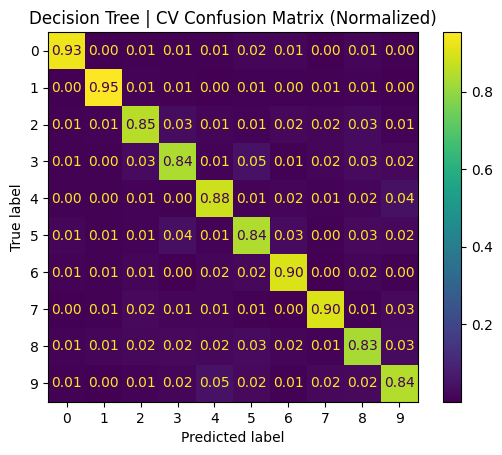

In [10]:
# ✅ 혼동행렬(정규화)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 10x10 matrix
cm = confusion_matrix(y, y_pred_dt, labels=np.arange(10))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

ConfusionMatrixDisplay(cm_norm).plot(values_format=".2f", cmap="viridis", colorbar=True);
plt.title("Decision Tree | CV Confusion Matrix (Normalized)")
plt.show()

8️⃣ 오분류된 예시 이미지 시각화

오분류 개수: 8539


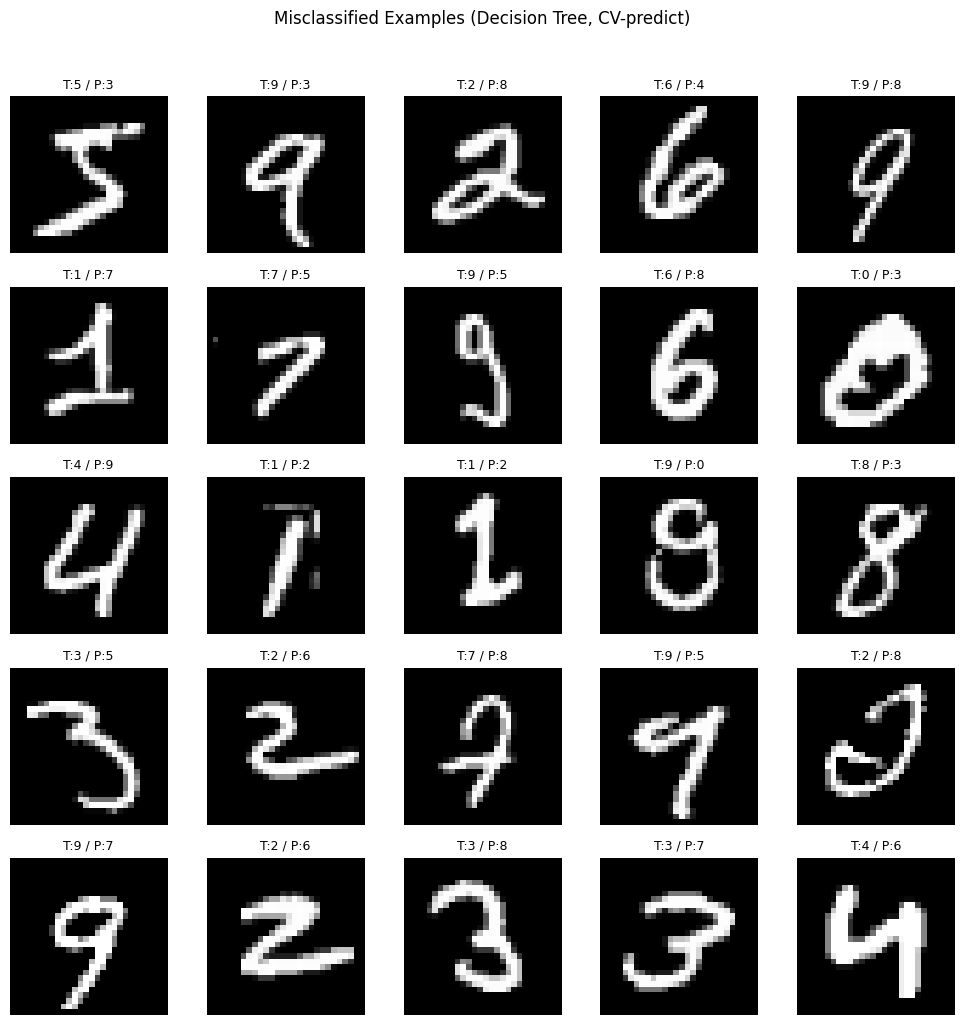

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.tree import DecisionTreeClassifier

# 오분류된 이미지들의 인덱스 추출
mis_idx = np.where(y != y_pred_dt)[0]
print("오분류 개수:", len(mis_idx))

# 앞에서부터 25개만
n_show = min(25, len(mis_idx))
imgs = X[mis_idx[:n_show]].reshape(n_show, 28, 28)
true_labels = y[mis_idx[:n_show]]
pred_labels = y_pred_dt[mis_idx[:n_show]]

cols = 5
rows = (n_show + cols - 1)//cols
plt.figure(figsize=(10, 2*rows))
for i in range(n_show):
    ax = plt.subplot(rows, cols, i+1)
    ax.imshow(imgs[i], cmap="gray")
    ax.set_title(f"T:{true_labels[i]} / P:{pred_labels[i]}", fontsize=9)
    ax.axis("off")
plt.suptitle("Misclassified Examples (Decision Tree, CV-predict)", y=1.02)
plt.tight_layout()
plt.show()


In [13]:
print("✅ 최적 파라미터:", dt_gs.best_params_)
print("✅ 최적 모델 객체:", best_dt)

✅ 최적 파라미터: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 5, 'min_samples_split': 2}
✅ 최적 모델 객체: DecisionTreeClassifier(class_weight='balanced', max_depth=30,
                       min_samples_leaf=5, random_state=42)


# 모델 저장

In [14]:
from joblib import dump
import json

# ✅ 저장할 파일명 (버전 넘버 방식)
model_path = "final_decisiontree_v1.joblib"
meta_path  = "final_decisiontree_v1.json"

# 1) 모델 저장 (best_dt는 GridSearch 후 얻은 최적 모델)
dump(best_dt, model_path)
print(f"💾 모델 저장 완료: {model_path}")

# 2) 메타 정보(하이퍼파라미터, CV 성능 등) 저장
meta = {
    "best_params": dt_gs.best_params_,
    "best_cv_accuracy": float(dt_gs.best_score_),
    "cv_n_splits": getattr(cv, "n_splits", None),
    "model_class": type(best_dt).__name__,
    "version": "v1"
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"📝 메타 데이터 저장 완료: {meta_path}")


💾 모델 저장 완료: final_decisiontree_v1.joblib
📝 메타 데이터 저장 완료: final_decisiontree_v1.json


# handmade test

In [14]:
from joblib import load
import json

# 1️⃣ 모델 불러오기
model_path = "final_decisiontree_v1.joblib"
meta_path  = "final_decisiontree_v1.json"

best_dt_loaded = load(model_path)
print(f"✅ 모델 로드 완료: {model_path}")

# 2️⃣ 메타 정보 불러오기 (선택)
with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

print("📄 모델 메타 정보:")
for k, v in meta.items():
    print(f"  {k}: {v}")


✅ 모델 로드 완료: final_decisiontree_v1.joblib
📄 모델 메타 정보:
  best_params: {'class_weight': 'balanced', 'max_depth': 30, 'min_samples_leaf': 5, 'min_samples_split': 2}
  best_cv_accuracy: 0.8780142857142857
  cv_n_splits: 5
  model_class: DecisionTreeClassifier
  version: v1


keys: ['images', 'labels']
🧪 Handmade Test | Accuracy: 0.1409258150081287

📄 Classification Report (Handmade Test)
              precision    recall  f1-score   support

           0     0.2556    0.0395    0.0684      1166
           1     0.4628    0.0477    0.0866      1173
           2     0.1044    0.0669    0.0816      1180
           3     0.1486    0.2756    0.1931      1183
           4     0.1909    0.0997    0.1310      1173
           5     0.0895    0.0955    0.0924      1183
           6     0.1129    0.1642    0.1338      1169
           7     0.1549    0.5319    0.2399      1160
           8     0.1236    0.0672    0.0871      1161
           9     0.0935    0.0202    0.0332      1139

    accuracy                         0.1409     11687
   macro avg     0.1737    0.1408    0.1147     11687
weighted avg     0.1738    0.1409    0.1149     11687



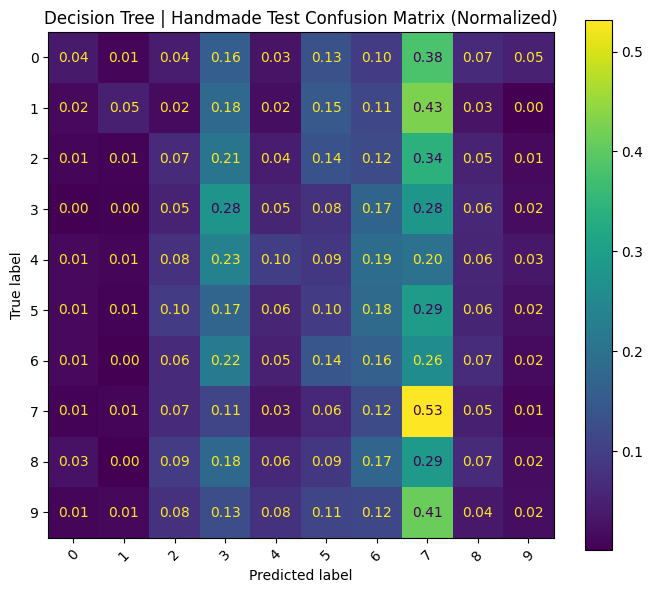

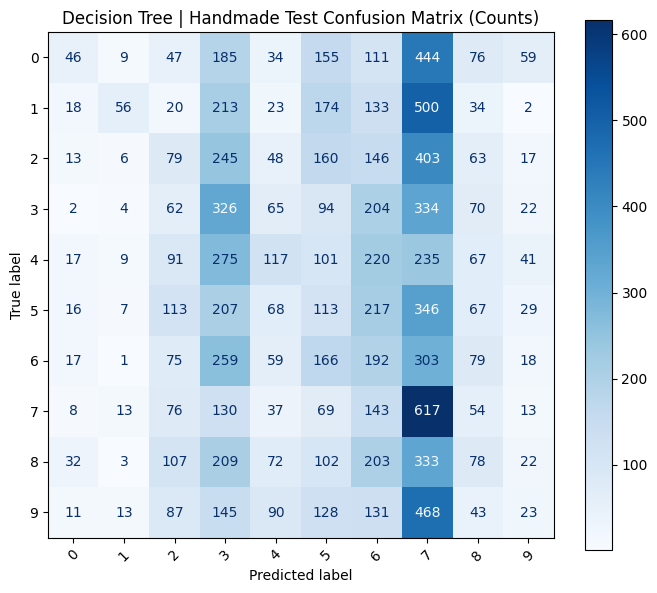

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1) handmade npz 로드
d = np.load("custom_MNIST2.npz", allow_pickle=True)

print("keys:", list(d.keys()))
Xh = d["images"]   # (N,28,28) 또는 (N,784)
yh = d["labels"]

# 2) 모양 정리: (N,28,28) -> (N,784)
if Xh.ndim == 3 and Xh.shape[1:] == (28, 28):
    Xh = Xh.reshape(len(Xh), -1).astype(np.float32)
else:
    Xh = Xh.astype(np.float32)

# 4) 레이블 타입 정리
yh = yh.astype(int)

# 5) 모델 선택 (하나만 활성화)
model=best_dt_loaded

# 6) 예측 & 성능 지표
y_pred_h = model.predict(Xh)

print("🧪 Handmade Test | Accuracy:", accuracy_score(yh, y_pred_h))
print("\n📄 Classification Report (Handmade Test)")
print(classification_report(yh, y_pred_h, digits=4, zero_division=0))

# 7) 혼동행렬 (정규화/카운트 둘 다 보고 싶을 때)
labels = np.arange(10)  # handmade 라벨이 0~9라면 고정하는 게 비교에 안전

# (a) 정규화
cm = confusion_matrix(yh, y_pred_h, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    values_format=".2f", cmap="viridis", ax=ax, colorbar=True
)
ax.set_title("Decision Tree | Handmade Test Confusion Matrix (Normalized)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# (b) 원시 카운트(선택)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    values_format="d", cmap="Blues", ax=ax, colorbar=True
)
ax.set_title("Decision Tree | Handmade Test Confusion Matrix (Counts)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


# handmade cleaning data test

## final_gu.npz : custom_MNIST2.npz cleaning

keys: ['X', 'y']
🧪 Handmade Test | Accuracy: 0.13271155985282793

📄 Classification Report (Handmade Test)
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      1166
           1     0.0000    0.0000    0.0000      1173
           2     0.0648    0.0297    0.0407      1180
           3     0.0857    0.1919    0.1184      1183
           4     0.1989    0.0912    0.1251      1173
           5     0.0658    0.0456    0.0539      1183
           6     0.0978    0.1865    0.1283      1169
           7     0.1964    0.7819    0.3139      1160
           8     0.0000    0.0000    0.0000      1161
           9     0.0104    0.0026    0.0042      1139

    accuracy                         0.1327     11687
   macro avg     0.0720    0.1329    0.0784     11687
weighted avg     0.0721    0.1327    0.0785     11687



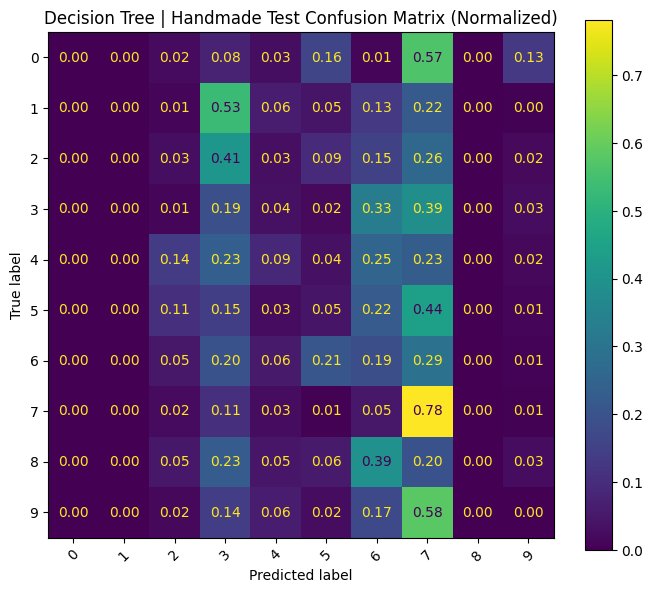

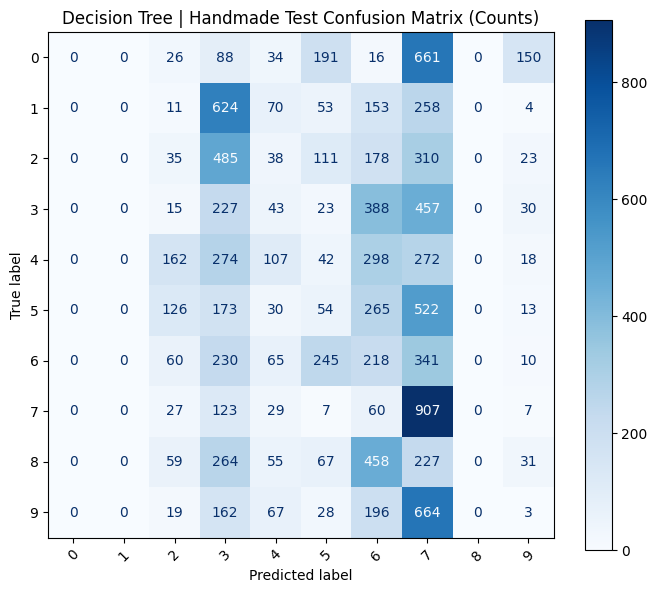

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1) handmade npz 로드
d = np.load("final_gu.npz", allow_pickle=True)

print("keys:", list(d.keys()))
Xh = d["X"]   # (N,28,28) 또는 (N,784)
yh = d["y"]

# 2) 모양 정리: (N,28,28) -> (N,784)
if Xh.ndim == 3 and Xh.shape[1:] == (28, 28):
    Xh = Xh.reshape(len(Xh), -1).astype(np.float32)
else:
    Xh = Xh.astype(np.float32)

# 4) 레이블 타입 정리
yh = yh.astype(int)

# 5) 모델 선택 (하나만 활성화)
model=best_dt_loaded

# 6) 예측 & 성능 지표
y_pred_h = model.predict(Xh)

print("🧪 Handmade Test | Accuracy:", accuracy_score(yh, y_pred_h))
print("\n📄 Classification Report (Handmade Test)")
print(classification_report(yh, y_pred_h, digits=4, zero_division=0))

# 7) 혼동행렬 (정규화/카운트 둘 다 보고 싶을 때)
labels = np.arange(10)  # handmade 라벨이 0~9라면 고정하는 게 비교에 안전

# (a) 정규화
cm = confusion_matrix(yh, y_pred_h, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
    values_format=".2f", cmap="viridis", ax=ax, colorbar=True
)
ax.set_title("Decision Tree | Handmade Test Confusion Matrix (Normalized)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# (b) 원시 카운트(선택)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    values_format="d", cmap="Blues", ax=ax, colorbar=True
)
ax.set_title("Decision Tree | Handmade Test Confusion Matrix (Counts)")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
